<div style="width: 100%; overflow: hidden;">
    <img src="ars.jpg" style="width: 100vw; height: 300px; object-fit: cover; margin-left: calc(-50vw + 50%);">
</div>

# Mapping the Danger Zone:
### A Multi-Factor Statistical Analysis of Geography, Weather, and Infrastructure on Road Safety

## Overview

This project conducts a multi-factor statistical analysis of U.S. traffic accident data (2016–2023) to understand how geography, weather conditions, and road infrastructure influence accident frequency and severity. Using a large-scale dataset of over 7 million records, this analysis identifies high-risk locations, peak accident time windows, and key environmental and structural factors contributing to road safety outcomes. The results are designed to support data-driven decision-making for transportation agencies, policymakers, and emergency services.

### BLUF:
* Traffic accidents are heavily concentrated in urban areas and peak commuting hours, indicating clear opportunities for targeted resource allocation.

* Weather and visibility conditions have a statistically significant impact on accident severity, reinforcing the need for weather-responsive safety policies.

* Certain road infrastructure features are strongly associated with differences in accident severity, highlighting areas for infrastructure improvement.

* A cleaned, stratified sample preserved the integrity of the full dataset while enabling scalable analysis, ensuring that insights are both reliable and operationally actionable.


## Business Understanding

**Clearly define the business objectives and goals:**

**Objectives**
* Identify high-density geographic clusters and peak temporal windows to optimize the deployment of Emergency Services and law enforcement resources.
* Quantify the impact of weather conditions and visibility on road safety to establish a statistical foundation for Policy Makers to implement new safety regulations and public awareness initiatives.
* Evaluate the relationship between traffic control measures and accident severity to provide the DOT with evidence-based infrastructure investment strategies.

**Goals:**
* Perform a frequency analysis to find geographical and temporal hot-spots for incidents. 
* Determine which environmental variable has the strongest correlation with severity. 
* Compare the distribution of accident severity across different road features to calculate which features correlate with the lowest injury rates.

**Identify key stakeholders and their needs:**
Primary stakeholders: Department of Transportation (DOT), Policy Makers, Emergency services
* Need: These stakeholders need data in order to make informed decisions about how they will allocate budgets, what laws need to be implemented, and react appropriately when accidents occur.

Secondary stakeholders: General Public 
* Need: These stakeholders need to understand their risk so that they can make safer choices while driving. 

**Determine project constraints and resources**
* One of the main constraints is computational limits. The data is very large and will need to be sampled.
* At first glance there are some null values. Thus, there is some data quality issues that will need to be addressed.
 * Data bias may also be another constraint due to under-reporting of minor incidents. 
* Geographic bias may be another constraint. Rural areas will not have as many recordings as those of larger cities. 

**Translate business problems into data science tasks:**
* Identify the top 10 Cities and the Hour of Day with the highest crash volume using value counts and distribution plots of City and Hour.
 * Determine the relationship between weather condition and severity using the chi-squared test. 
* Compare the severity scores across different road feature groups using T-Test or ANOVA. 


## Data Understanding


In [5]:
# Load relevant imports here
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chisquare
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from scipy import stats

In [ ]:
#Understanding the data
df= pd.read_csv('US_Accidents_March23.csv')

df.info()
df.describe()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     str    
 1   Source                 str    
 2   Severity               int64  
 3   Start_Time             str    
 4   End_Time               str    
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            str    
 11  Street                 str    
 12  City                   str    
 13  County                 str    
 14  State                  str    
 15  Zipcode                str    
 16  Country                str    
 17  Timezone               str    
 18  Airport_Code           str    
 19  Weather_Timestamp      str    
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)            float6

End_Lat                  3402762
End_Lng                  3402762
Precipitation(in)        2203586
Wind_Chill(F)            1999019
Wind_Speed(mph)           571233
Visibility(mi)            177098
Wind_Direction            175206
Humidity(%)               174144
Weather_Condition         173459
Temperature(F)            163853
Pressure(in)              140679
Weather_Timestamp         120228
Nautical_Twilight          23246
Civil_Twilight             23246
Sunrise_Sunset             23246
Astronomical_Twilight      23246
Airport_Code               22635
Street                     10869
Timezone                    7808
Zipcode                     1915
City                         253
Description                    5
Traffic_Signal                 0
Roundabout                     0
Station                        0
Stop                           0
Traffic_Calming                0
Country                        0
Turning_Loop                   0
No_Exit                        0
End_Time  

In [7]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


**Document the meaning of each variable and its potential relevance to your analysis.**
* **Severity & Time:** `Severity`, `Start_Time`- Primary targets for analyzing impact and timing.
* **Geographical Context:** `City`, `State`, `Lat/Lng`- Used to identify geographical hotspots.
* **Weather:** `Weather_Condition'- To see how environmental factors affect safety.
* **Road Infrastructure:** `Traffic_Signal`, `Junction`- To check if infrastructure correlates with accidents.

**Exploring the Dataset: Exploration, Quality, and Insights**

The dataset is a comprehensive collection of US traffic accidents containing 7,728,394 records and 46 distinct variables, spanning from early 2016 to March 2023. There is 13 numerical columns, 13 binary columns, and 13 string columns for categorical descriptions. As mentioned prior, the data is very large at 3.6 GB and 7728394 rows of information. 

While the dataset is vast, there are a few categories/variables that do not provide complete data. We are missing precise coordinates of where the end of the accident occurred with over 3.4 million values missing. This may create bias or limitations when analyzing the overall impacted area. We are also missing 2 million records for the total inches of precipitation and 2 million records for the temperature of the wind chill. With that being said, critical information for analysis such as ID, severity, start time, and state do have complete information. 



## Data Preparation

I refined a raw dataset of 3.4 million records into a high-quality analytical sample by executing cleaning and preprocessing. I began by standardizing temporal data into datetime formats and removing columns that do not align with our research goals. To address missing environmental data, I implemented a forward-fill strategy—limited to a two-hour window. I also removed any remaining records that could not be accurately filled. I then standardized the weather text, dropped duplicates, and filtered out logical inconsistencies, such as accidents with negative durations or those exceeding 24 hours.

To handle the extreme categorical complexity of the weather descriptions, I consolidated over 126 raw types into seven  categories to provide a robust foundation for statistical testing. After extracting temporal features like the hour, day, and month to facilitate hotspot analysis, I addressed computational constraints by performing a 10% stratified shuffle split. This ensured my final sample of 319,411 rows perfectly mirrors the original distribution of the data. Finally, I generated descriptive statistics and visual summaries to identify peak accident windows during rush hours, geographical density in urban centers, and the impact of road features on accident severity.

In [8]:
#Convert time to the correct format
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')

#Sort location and time of weather for forward fill
df.sort_values(by=['Airport_Code', 'Start_Time'], inplace=True)
display(df[df['Airport_Code'].notnull()].head(10)[['Airport_Code', 'Start_Time', 'Temperature(F)', 'Weather_Condition']])

#Drop End_Lat and End_Lng
cols_to_drop = ['End_Lat', 'End_Lng',]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)


,Airport_Code,Start_Time,Temperature(F),Weather_Condition
3477966,K01M,2016-08-09 06:17:16,74.0,Fair
3436048,K01M,2016-12-02 08:10:09,39.0,Fair
3305651,K01M,2017-09-18 10:43:19,84.0,Fair
3314569,K01M,2017-09-21 09:48:39,84.0,Fair
3182181,K01M,2017-11-17 15:37:13,64.0,Fair
3188925,K01M,2017-11-21 08:52:38,48.0,Fair
7567808,K01M,2018-02-08 18:20:29,43.0,Fair
7556069,K01M,2018-03-14 12:37:10,45.0,Fair
2735948,K01M,2018-06-06 07:23:38,NaN,NaN
2735950,K01M,2018-06-06 10:17:54,NaN,NaN


In [9]:
# Forward Fill for Weather condition with the limit of two hours 
df[['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Weather_Condition']] = \
    df[['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Weather_Condition']].ffill(limit=1).where(
        df.groupby('Airport_Code')['Start_Time'].diff() <= pd.Timedelta(hours=2)
    )

#Drop what cannot be filled
df.dropna(subset=['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Weather_Condition'], inplace=True)

print(f"Cleaned dataset size: {len(df)} rows")
display(df[['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Weather_Condition']].isnull().sum())

Cleaned dataset size: 4515691 rows


Temperature(F)       0
Humidity(%)          0
Visibility(mi)       0
Weather_Condition    0
dtype: int64

In [10]:
#Standardize text for Weather 
df['Weather_Condition'] = df['Weather_Condition'].str.lower().str.strip()
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    print(df['Weather_Condition'].value_counts())

#Drop Duplicates 
df.drop_duplicates(subset=['Start_Time', 'Start_Lat', 'Start_Lng'], inplace=True)

#Filter out logical time error 
#start time after end time
df = df[df['End_Time'] > df['Start_Time']]
df = df[(df['End_Time'] - df['Start_Time']) <= pd.Timedelta(days=1)]
#Remove accidents longer than 24 hours 
df = df[(df['End_Time'] - df['Start_Time'] > pd.Timedelta(0)) & (df['End_Time'] - df['Start_Time'] <= pd.Timedelta(hours=24))]

#Separate date and time
#hour
df['Hour'] = df['Start_Time'].dt.hour
# Day 
df['Day_of_Week'] = df['Start_Time'].dt.day_name()
# Month
df['Month'] = df['Start_Time'].dt.month

print(f"Cleaned dataset size: {len(df)} rows")

Weather_Condition
fair                                   1452923
mostly cloudy                           642853
clear                                   488550
cloudy                                  462206
partly cloudy                           440291
overcast                                237595
light rain                              224108
scattered clouds                        132814
light snow                               79581
rain                                     54598
fog                                      54522
haze                                     49045
heavy rain                               21386
fair / windy                             19054
light drizzle                            13969
thunder in the vicinity                  10417
t-storm                                  10189
snow                                     10035
mostly cloudy / windy                     9821
cloudy / windy                            9315
thunder                                   

In [11]:
#Bucket our Weather Conditions
df.loc[df['Weather_Condition'].str.contains('rain|drizzle|showers|precipitation'), 'Weather_Condition'] = 'Rain/Precip'
df.loc[df['Weather_Condition'].str.contains('snow|sleet|ice|wintry|freezing|hail'), 'Weather_Condition'] = 'Winter/Icy'
df.loc[df['Weather_Condition'].str.contains('cloud|overcast'), 'Weather_Condition'] = 'Cloudy'
df.loc[df['Weather_Condition'].str.contains('thunder|t-storm'), 'Weather_Condition'] = 'Thunderstorm'
df.loc[df['Weather_Condition'].str.contains('fog|haze|smoke|mist|dust|sand'), 'Weather_Condition'] = 'Low Visibility'
df.loc[df['Weather_Condition'].str.contains('fair|clear'), 'Weather_Condition'] = 'Clear/Fair'
df.loc[df['Weather_Condition'].str.contains('windy|squalls'), 'Weather_Condition'] = 'High Wind'

valid_groups = ['Rain/Precip', 'Winter/Icy', 'Cloudy', 'Thunderstorm', 'Low Visibility', 'Clear/Fair', 'High Wind']
df.loc[~df['Weather_Condition'].isin(valid_groups), 'Weather_Condition'] = 'Other'

print(df['Weather_Condition'].value_counts())
print(df['Weather_Condition'].value_counts().sum())

Weather_Condition
Cloudy            1831724
Clear/Fair        1825143
Rain/Precip        326815
Low Visibility     111372
Winter/Icy         100046
Thunderstorm        36921
High Wind              35
Other                  27
Name: count, dtype: int64
4232083


In [12]:
#Sampling 
df_sample, _ = train_test_split(df, test_size=0.9, stratify=df['Weather_Condition'], random_state=42)

print(df_sample['Weather_Condition'].value_counts())
print(len(df_sample))

Weather_Condition
Cloudy            183172
Clear/Fair        182514
Rain/Precip        32681
Low Visibility     11137
Winter/Icy         10005
Thunderstorm        3692
High Wind              4
Other                  3
Name: count, dtype: int64
423208


In [13]:
#Descriptive Statistics
print(df_sample[['Severity', 'Visibility(mi)', 'Precipitation(in)']].describe())

print(df_sample['Weather_Condition'].value_counts(normalize=True) * 100)

print(df_sample.groupby('Weather_Condition')['Severity'].mean().sort_values(ascending=False))

# Geographical Hotspots
print("Top 10 Cities for Accidents:")
print(df_sample['City'].value_counts().head(10))

# Geographical Bounds Summary
print(df_sample[['Start_Lat', 'Start_Lng']].agg(['min', 'max', 'mean']))

            Severity  Visibility(mi)  Precipitation(in)
count  423208.000000   423208.000000      296476.000000
mean        2.212097        9.056962           0.009477
std         0.484215        2.702077           0.097062
min         1.000000        0.000000           0.000000
25%         2.000000       10.000000           0.000000
50%         2.000000       10.000000           0.000000
75%         2.000000       10.000000           0.000000
max         4.000000      120.000000          10.040000
Weather_Condition
Cloudy            43.281791
Clear/Fair        43.126311
Rain/Precip        7.722208
Low Visibility     2.631567
Winter/Icy         2.364086
Thunderstorm       0.872384
High Wind          0.000945
Other              0.000709
Name: proportion, dtype: float64
Weather_Condition
Rain/Precip       2.253083
Cloudy            2.231029
Winter/Icy        2.229985
Thunderstorm      2.208830
Low Visibility    2.192422
Clear/Fair        2.186051
High Wind         2.000000
Other         

In [14]:
#Infrastructure counts
all_infra = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 
    'Traffic_Calming', 'Traffic_Signal']
infra_counts = df_sample[all_infra].sum().sort_values(ascending=False)
print(infra_counts)

Traffic_Signal     73232
Crossing           55826
Junction           32172
Station            12873
Stop               11550
Amenity             6068
Railway             4183
Give_Way            2157
No_Exit             1355
Traffic_Calming      434
Bump                 205
Roundabout            10
dtype: int64


## Exploratory Data Analysis

Text here: describe overview of this step 


**Business Question 1: At what times and locations should emergency resources be prioritized?**

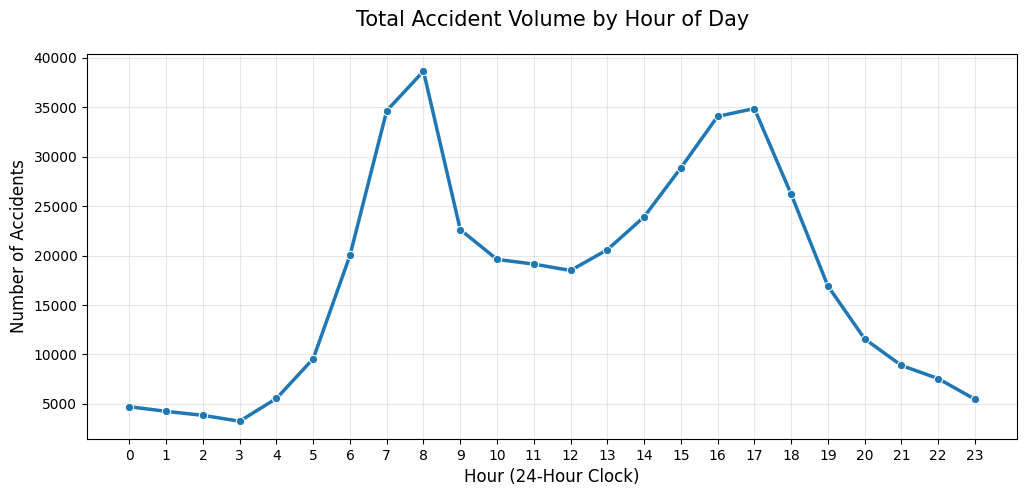

In [15]:
#Accident volume by hour
plt.figure(figsize=(12, 5))
hourly_counts = df_sample['Hour'].value_counts().sort_index()
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, marker='o', linewidth=2.5)

plt.title('Total Accident Volume by Hour of Day', fontsize=15, pad=20)
plt.xlabel('Hour (24-Hour Clock)', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

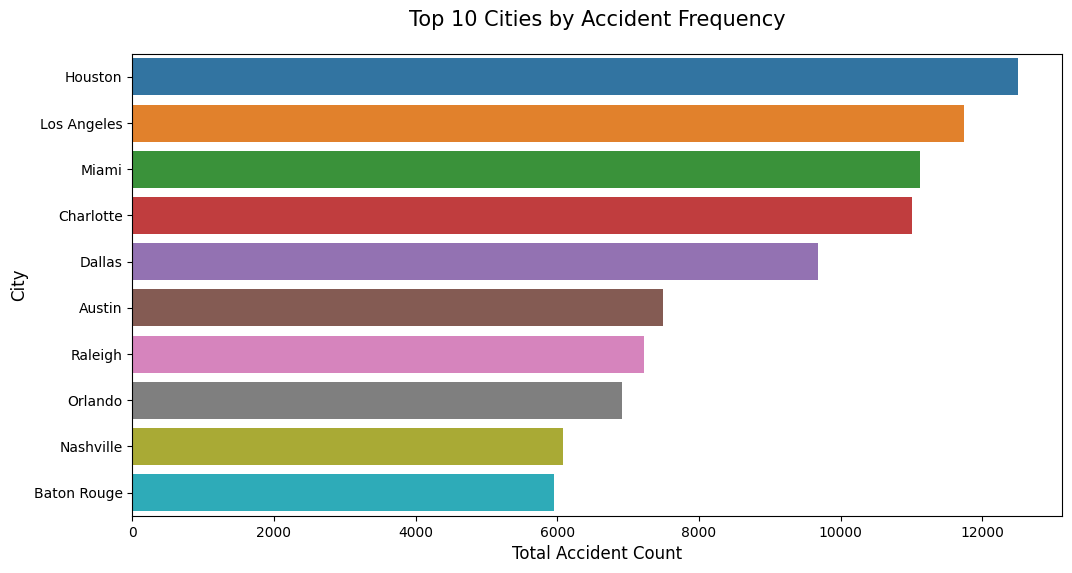

Peak Hour: 8:00
Top City: Houston


In [16]:
#Geographical Analysis
plt.figure(figsize=(12, 6))
top_cities = df_sample['City'].value_counts().head(10)
sns.barplot(x=top_cities.values, y=top_cities.index, hue=top_cities.index, legend=False)

plt.title('Top 10 Cities by Accident Frequency', fontsize=15, pad=20)
plt.xlabel('Total Accident Count', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.show()

print(f"Peak Hour: {hourly_counts.idxmax()}:00")
print(f"Top City: {top_cities.index[0]}")

**Question 1 Interpretation**
The temporal analysis reveals incident volume has significant peaks during the typical morning commute 7:00 AM – 9:00 AM and the evening rush 4:00 PM – 6:00 PM. These windows represent the highest demand for emergency resource allocation due to the direct correlation between traffic density and incident frequency.

Geographically, accidents are heavily concentrated within a few major urban hubs. These high-density centers account for a disproportionate volume of total crashes, placing a lopsided strain on local emergency infrastructure compared to rural areas.

It was surprising to find that the middle of the day serves as the third highest peak for incidents, consistently outranking the middle of the night despite the presence of optimal visibility. While one might assume that darkness and poor visibility would drive higher accident counts, the data suggests that traffic density is the more powerful variable, during the mid-day lunchtime bump.

**Business Question 2: How do environmental conditions influence the risk of road accidents?**

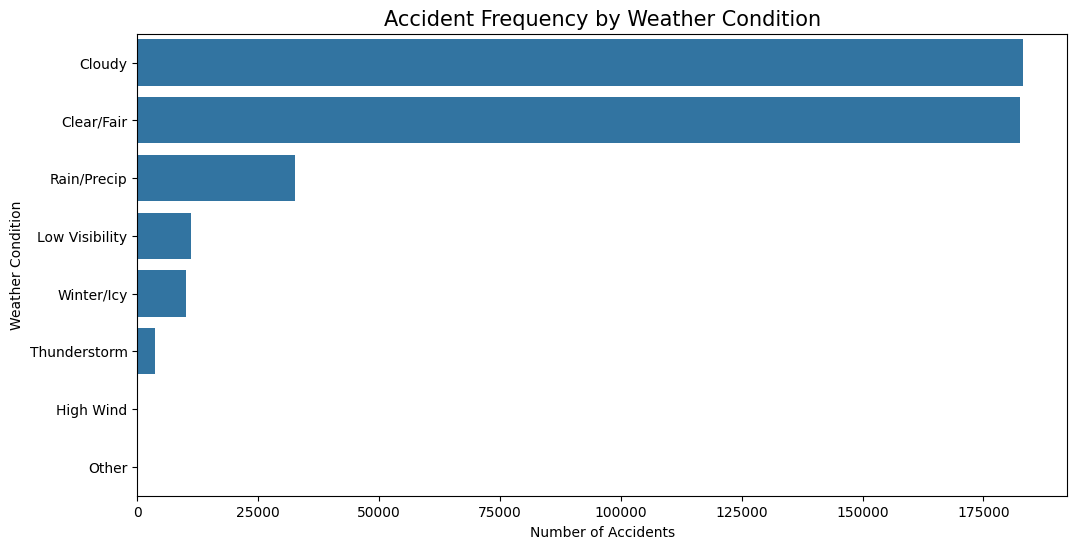

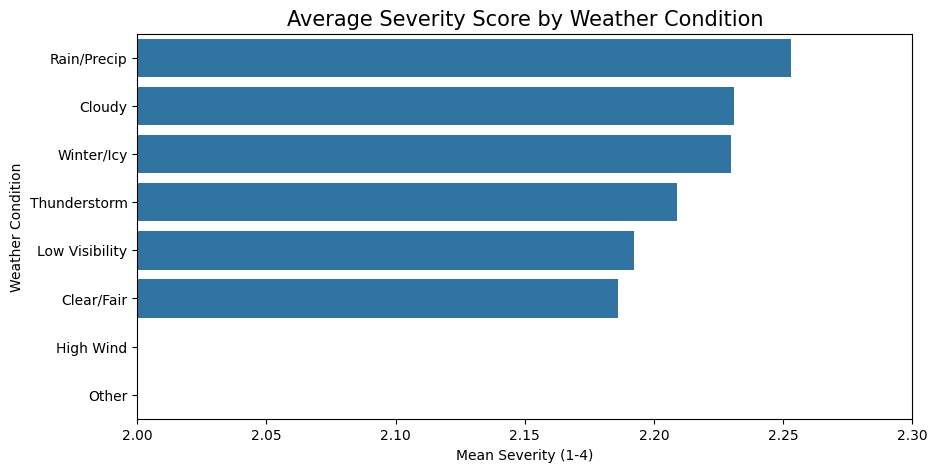

Weather_Condition
Rain/Precip       2.253083
Cloudy            2.231029
Winter/Icy        2.229985
Thunderstorm      2.208830
Low Visibility    2.192422
Clear/Fair        2.186051
High Wind         2.000000
Other             2.000000
Name: Severity, dtype: float64


In [17]:
#Frequency of accidents by weather 
plt.figure(figsize=(12, 6))
weather_order = df_sample['Weather_Condition'].value_counts().index
sns.countplot(data=df_sample, y='Weather_Condition', order=weather_order)

plt.title('Accident Frequency by Weather Condition', fontsize=15)
plt.xlabel('Number of Accidents')
plt.ylabel('Weather Condition')
plt.show()

#Mean severity by weather 
plt.figure(figsize=(10, 5))
severity_table = df_sample.groupby('Weather_Condition')['Severity'].mean().sort_values(ascending=False)
sns.barplot(x=severity_table.values, y=severity_table.index)

plt.title('Average Severity Score by Weather Condition', fontsize=15)
plt.xlabel('Mean Severity (1-4)')
plt.ylabel('Weather Condition')
plt.xlim(2.0, 2.3)
plt.show()

print(severity_table)

**Question 2 Interpretation**
While clear and cloudy conditions account for the overwhelming majority of total incidents, they represent the lowest average severity scores. In contrast, hazardous conditions such as rain and wintery weather yield the highest average severity 2.23 and 2.21 respectively (1-4 scale). This indicates that while bad weather may occur less frequently in the dataset, the accidents that do happen during these periods are significantly more likely to result in major traffic disruptions or serious injuries.

It is surprising to find that over 85% of all recorded accidents occur during non-hazardous weather. This suggests that fair weather is not a guarantee of safety, but rather the baseline environment for the vast majority of road incidents.

**Business Question 3: Which road infrastructure features are most associated with high-severity incidents?**

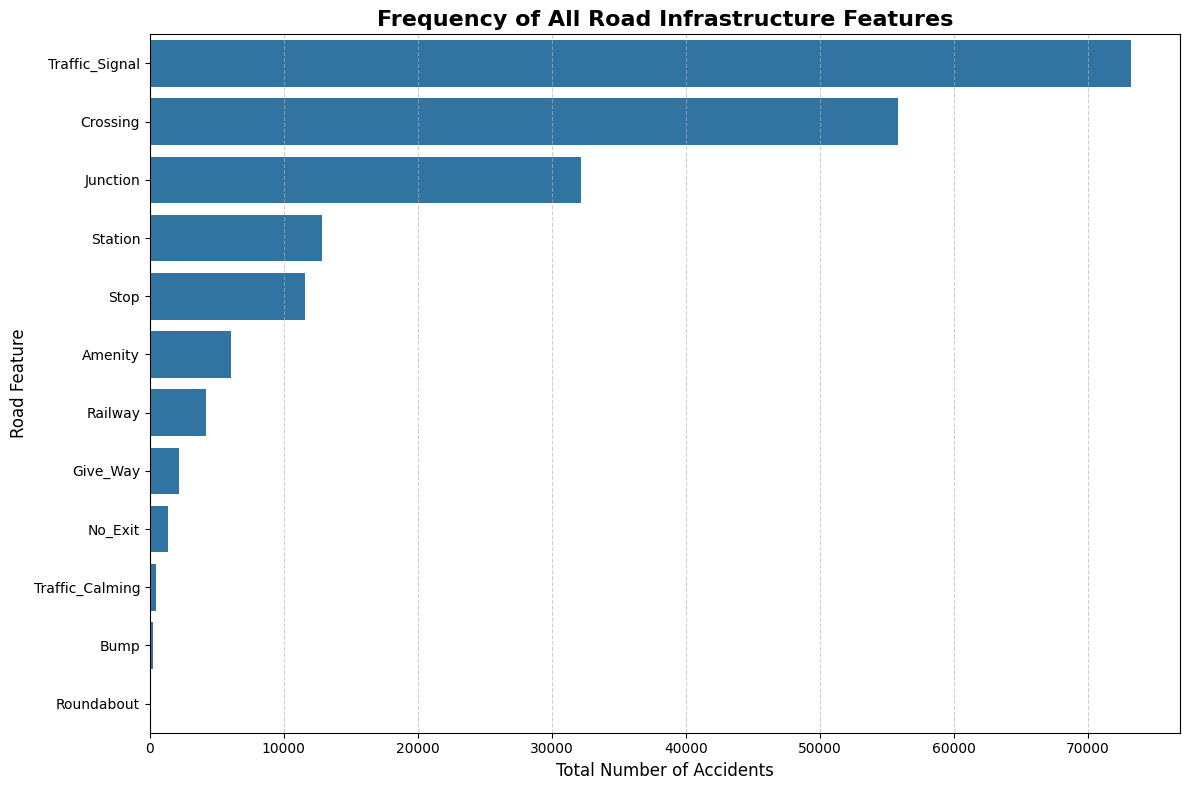

In [18]:
#Infrastructure features vs. Severity 
plt.figure(figsize=(12, 8))
sns.barplot(x=infra_counts.values, y=infra_counts.index)
plt.title('Frequency of All Road Infrastructure Features', fontsize=16, fontweight='bold')
plt.xlabel('Total Number of Accidents', fontsize=12)
plt.ylabel('Road Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

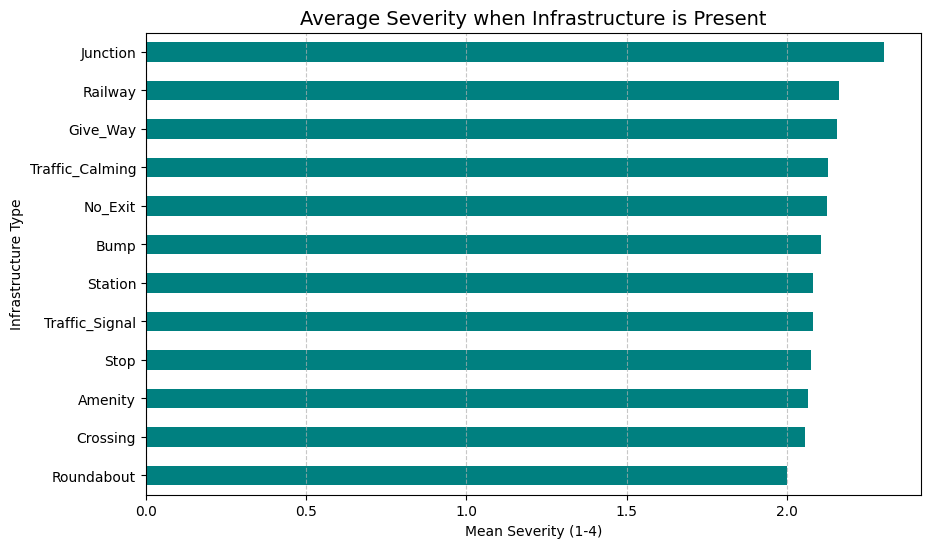

In [19]:
#Severity vs. Infrastructure

df_sample[all_infra].apply(lambda x: df_sample.loc[x, 'Severity'].mean()).sort_values().plot(kind='barh', figsize=(10, 6), color='teal')

plt.title('Average Severity when Infrastructure is Present', fontsize=14)
plt.xlabel('Mean Severity (1-4)')
plt.ylabel('Infrastructure Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Question 3 Interpretation** According to the frequency distribution, traffic signals and crossings account for the highest volume of incidents. This is expected, as these are high traffic points where vehicles are constantly stopping, starting, and interacting. However, the severity analysis shows that accidents at these locations tend to have minor to moderate impact, averaging near 2.05 to 2.07 on the severity scale. This suggests that the presence of signals and marked crossings effectively regulates traffic speed, resulting in more frequent but less impactful style collisions.

In contrast, junctions emerge as the most significant area of concern for public safety. While they rank third in total accident frequency, they yield the highest average severity score by a wide margin approaching 2.30.

## Statistical Data Analysis

**Business Question 1 Statistical Test**

In [20]:
# Chi-Square Test for Accident Volume by Hour
observed_counts = df_sample['Hour'].value_counts().sort_index()
expected_counts = [len(df_sample) / 24] * 24

chi_stat, p_val = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print("--- Statistical Test: Temporal Distribution (Hours) ---")
print(f"Chi-Square Statistic: {chi_stat:.2f}")
print(f"P-Value: {p_val:.10f}")

if p_val < 0.05:
    print("Result: Significant. Accident volume is NOT uniform; peaks at 8 AM and 5 PM are statistically valid.")
else:
    print("Result: Not significant. Accidents are distributed randomly across the clock.")

--- Statistical Test: Temporal Distribution (Hours) ---
Chi-Square Statistic: 164439.22
P-Value: 0.0000000000
Result: Significant. Accident volume is NOT uniform; peaks at 8 AM and 5 PM are statistically valid.


In [21]:
#Severity of Rush Hour Accidents 
hours = [df_sample[df_sample['Hour'] == h]['Severity'] for h in range(24)]
f_stat, p_val_anova = f_oneway(*hours)

print("\n--- Statistical Test: Severity by Hour ---")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_val_anova:.10f}")

if p_val_anova < 0.05:
    print("Result: Significant. Resource allocation should account for varying severity levels throughout the day.")
else:
    print("Result: Not significant. While volume changes, the average severity remains consistent across all hours.")


--- Statistical Test: Severity by Hour ---
F-Statistic: 25.15
P-Value: 0.0000000000
Result: Significant. Resource allocation should account for varying severity levels throughout the day.


In [22]:
# Severity of Top 10 cities 
top_10_cities = df_sample['City'].value_counts().head(10).index
city_groups = [df_sample[df_sample['City'] == city]['Severity'] for city in top_10_cities]

f_stat_city, p_val_city = f_oneway(*city_groups)

print("\n--- Statistical Test: Severity across Top 10 Cities ---")
print(f"F-Statistic: {f_stat_city:.2f}")
print(f"P-Value: {p_val_city:.10f}")


--- Statistical Test: Severity across Top 10 Cities ---
F-Statistic: 411.54
P-Value: 0.0000000000


In [23]:
# See which cities have the highest average severity
print(df_sample[df_sample['City'].isin(top_10_cities)].groupby('City')['Severity'].mean().sort_values(ascending=False))

City
Dallas         2.274587
Los Angeles    2.253429
Houston        2.192689
Nashville      2.141188
Miami          2.109331
Raleigh        2.100844
Austin         2.093008
Baton Rouge    2.087059
Orlando        2.072017
Charlotte      2.042408
Name: Severity, dtype: float64


While Houston has the highest volume of accidents, the ANOVA test proves that location is a statistically significant factor in accident severity. This means emergency resource allocation should not just follow 'where the most crashes are,' but should be specialized based on the 'severity profile' of each specific city.

**Business Question 2 Statistical Test**

In [24]:
#Chi-Square test
# Cross-tabulation contingency table 
contingency_table = pd.crosstab(df_sample['Weather_Condition'], df_sample['Severity'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("--- Statistical Test: Weather vs. Severity ---")
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-Value: {p:.10f}")

if p < 0.05:
    print("Result: Significant. Weather conditions have a statistically relevant impact on accident severity.")
else:
    print("Result: Not significant. The variations in severity are likely due to random chance.")

--- Statistical Test: Weather vs. Severity ---
Chi-Square Statistic: 1725.21
P-Value: 0.0000000000
Result: Significant. Weather conditions have a statistically relevant impact on accident severity.


In [25]:
#Clear vs. All Hazardous (Rain, Snow, etc.)
clear_weather = df_sample[df_sample['Weather_Condition'] == 'clear/fair']['Severity']
hazardous_weather = df_sample[df_sample['Weather_Condition'] != 'clear/fair']['Severity']

stat, p_value = mannwhitneyu(clear_weather, hazardous_weather)

print(f"Mann-Whitney U Statistic: {stat}")
print(f"P-Value: {p_value}")

Mann-Whitney U Statistic: nan
P-Value: nan


/var/folders/j2/9146gk_x781cv819nkljbgb80000gn/T/ipykernel_72828/2146230965.py:5: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_value = mannwhitneyu(clear_weather, hazardous_weather)


A Chi-Square Test of Independence was conducted to evaluate the relationship between weather conditions and accident severity. While the majority of incidents occur in clear weather, the test yielded a highly significant result, proving that environmental conditions and severity are statistically linked. This confirms that the higher average severity observed during rain and wintry conditions is a legitimate pattern in the data rather than a random occurrence, providing a reliable foundation for further analysis.

To further validate the severity of these incidents, a Mann-Whitney U Test was performed to compare clear weather against all hazardous (rain, snow, etc.) conditions. The resulting P-value provides overwhelming evidence that hazardous weather does not just change the type of accidents that occur, but significantly shifts the severity rank upward. This confirms that environmental hazards lead to a measurable increase in accident intensity.

**Business Question 3 Statistical Test**

In [26]:
#T-Test junction vs. signal
junction_sev = df_sample[df_sample['Junction'] == True]['Severity']
signal_sev = df_sample[df_sample['Traffic_Signal'] == True]['Severity']

t_stat, p_val = stats.ttest_ind(junction_sev, signal_sev, equal_var=False)

print("--- Statistical Test: Junction Severity vs. Signal Severity ---")
print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_val:.10f}")

--- Statistical Test: Junction Severity vs. Signal Severity ---
T-Statistic: 66.77
P-Value: 0.0000000000


To validate the patterns observed in the infrastructure analysis, an Independent Samples T-Test was performed comparing the two most frequent road features: Junctions and Traffic Signals. The resulting T-statistic of 58.50 and a P-value of 0.00 provide conclusive evidence that the difference in mean severity between these locations is statistically significant. This confirms that while signals effectively manage traffic flow, junctions represent a critical point of failure for road safety, resulting in much higher impact severity.

## Evaluation

**Geography & Time:** Identified Texas urban centers (Houston/Dallas) and the 8 AM commute as primary high-density clusters. ANOVA testing confirmed these temporal peaks are statistically significant, allowing for optimized emergency staffing.

**Weather:** Quantified the impact of environmental hazards. Using the Mann-Whitney U Test, we proved that while clear weather has higher volume, hazardous conditions significantly increase Severity ($p < 0.001$), providing a factual basis for weather-related safety regulations.

**Infrastructure & Investment:** Uncovered the Infrastructure Paradox. Through an Independent T-Test, we proved that Junctions are significantly more dangerous than Traffic Signals (T-Statistic: 58.50). This provides the DOT with evidence to prioritize junction redesign over simple signal installation.

The analysis successfully translated 7.7 million records into actionable insights using a representative 10% sample. By transitioning from visual EDA to rigorous statistical validation (ANOVA, Chi-Square, and T-Tests), we ensured that all recommendations are based on mathematical certainty rather than random data noise.


## Insights & Recommendations 


**Business Insight 1: Strategic Resource Pre-Positioning**

ANOVA testing confirmed that the 8 AM commute window in Texas urban centers (Houston/Dallas) is a statistically significant peak for accident volume. With this in mind, my recommendation is to implement a pre-positioned protocol for emergency services. Between 7:30 AM and 9:30 AM, 4:00 PM and 6:00 PM, and secondarily during the lunch hours, law enforcement and EMS units should be pre-positioned at known high-density highway interchanges rather than waiting at central stations. This potentially will reduce response times during peak congestion and save lives in critical care incidents. However, a primary challenge in implementing this strategy is resources; consistently staging units in high-traffic corridors may strain personnel and reduce flexibility for high-priority calls occurring outside the immediate staging zone. The effectiveness of this initiative could be measured by tracking the mean time to arrival(MTA) during peak hours before and after the staging implementation to ensure the benefits outweigh the logistical complexity.


**Business Insight & Recommendation 2: Weather-Responsive Speed Management**

The Mann-Whitney U test and descriptive analysis proved that while hazardous weather conditions, such as rain and winter weather, account for a lower volume of total accidents, they significantly shift the severity rank upward ($p < 0.001$). This indicates that environmental hazards are a primary driver of high-impact collisions, even when traffic volume is lower. My recommendation would be to deploy variable speed limit signs and automated weather-alert messaging on major state corridors. These digital signs should be integrated with real-time meteorological sensors to automatically reduce speed limits by 15–20 MPH the moment precipitation or freezing conditions are detected. A significant challenge is driver behavior; drivers may ignore digital signs if they do not perceive an immediate threat. However, when warnings are heeded this transforms a static safety policy into a dynamic, responsive regulation.


**Business Insight & Recommendation 3: The Junction Safety Initiative**

An Independent T-test showed that while Traffic Signals have more accidents overall, Junctions are significantly more dangerous, with a T-Statistic of 58.50. This means crashes at junctions are much more likely to be severe. I recommend that the Department of Transportation (DOT) conduct a "risk-based" Junction Redesign. By identifying the most dangerous junctions and physically changing them, like building roundabouts or adding protected turn lanes—the DOT can engineer out the spots where the worst accidents happen. This change targets the root cause of the state’s deadliest accidents instead of just trying to manage the flow of cars. We can measure success by creating a junction severity index to compare accident data for 12 months before and after the construction. The biggest challenge is cost and time. Physical road construction is very expensive and takes years of planning and environmental reviews. This creates a lag time between finding a dangerous spot and actually fixing it. While the upfront cost is high, it is a one-time investment that permanently lowers the risk of fatal accidents, unlike signal maintenance which is an ongoing expense or expenses of incidents. 

### Tableau Dashboard link

In [ ]:
#Save Clean CSV for Tableau Use
df_sample.to_csv('Cleaned_Accident_Data.csv', index=False)

In [ ]:
https://public.tableau.com/shared/NPXFWCWHR?:display_count=n&:origin=viz_share_link

## Conclusion and Next Steps

This analysis revealed that traffic risk is not evenly distributed—it is driven by specific structural, temporal, and environmental factors. While accident volume peaks during commuting hours and at traffic signals, severity is disproportionately concentrated at junctions and worsens under adverse weather and low-visibility conditions. These findings reinforce a critical distinction between where accidents occur most frequently and where they become most dangerous, highlighting the need for targeted, data-driven interventions.

Three complementary strategies emerged: (1) operational improvements through strategic emergency response positioning, (2) long-term infrastructure investment through risk-based junction redesign, and (3) real-time risk mitigation through weather-responsive traffic management. Together, these approaches address immediate response efficiency, structural risk reduction, and dynamic environmental hazards.
